# Carleman Benchmarking

Benchmark trajectory evaluation as the sequence length increases.

Methods:

1. **Sequential nonlinear solve:** SciPy `solve_ivp` with DOP853.
2. **Parallel nonlinear solve:** Euler and RK4 discretizations solved with DEER, quasi-DEER, ELK, quasi-ELK, Jacobi, and Picard.
3. **Linear Carleman estimate:** finite-section Carleman system simulated with `lsim`.

The sequence length \(L\) is the number of intervals, so each trajectory has \(L+1\) samples.

Recorded quantities:

- trajectory runtime;
- speedup versus SciPy;
- final-state error;
- fixed-point merit and merit per step;
- iteration count.

## Imports and parameters

In [1]:
import gc
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.integrate import solve_ivp
from scipy.special import lambertw
from scipy.sparse import csr_matrix

repo_candidates = [
    Path.cwd(),
    *Path.cwd().parents,
]

for candidate in repo_candidates:
    if (candidate / "src" / "ode_solvers").is_dir():
        repo_root = candidate
        break
else:
    raise FileNotFoundError(
        "Run this notebook from the Para-Seq repository or place it inside the repository."
    )

sys.path.insert(0, str(repo_root))

from src.ode_solvers import (
    lsim,
    make_initial_guess_batched,
    make_integrator_step,
    make_ode_drivers,
    solve_ode_fixed_step,
)
from src.algos.FixedPoint import jacobi_alg_batched, picard_alg_batched

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

sequence_powers = (10, 12, 14, 16, 17)
sequence_lengths = np.asarray([2**power for power in sequence_powers], dtype=int)

maximum_iterations = 12
solver_tolerance = 1e-6
scan_backend = "torch"
carleman_lsim_max_dense_scan_elements = 16_000_000
carleman_lsim_max_chunk_steps = 4096

method_specs = {
    "DEER": {"solver": "deer", "quasi": False},
    "Quasi-DEER": {"solver": "deer", "quasi": True},
    "ELK": {"solver": "elk", "quasi": False},
    "Quasi-ELK": {"solver": "elk", "quasi": True},
    "Jacobi": {"solver": "jacobi", "quasi": None},
    "Picard": {"solver": "picard", "quasi": None},
}

integrators = ("euler", "rk4")

print(f"Repository:       {repo_root}")
print(f"Parallel device:  {device}")
print(f"Parallel dtype:   {dtype}")
print(f"Sequence lengths: {sequence_lengths.tolist()}")

Repository:       /home/cpt/Documents/Github/Para-Seq
Parallel device:  cuda
Parallel dtype:   torch.float32
Sequence lengths: [1024, 4096, 16384, 65536, 131072]


## Benchmarking functions

Parallel nonlinear methods solve

$$
x_{k+1}=\Phi_h(t_k,x_k),
$$

with Euler or RK4 transitions.

The residual merit is

$$
\mathcal{M}
=
\frac{1}{2}
\sum_{k=0}^{L-1}
\left\|
x_{k+1}-\Phi_h(t_k,x_k)
\right\|_2^2.
$$

Plots use merit per step:

$$
\overline{\mathcal{M}}=\frac{\mathcal{M}}{L}.
$$

SciPy uses `max_step = T/L`. The Carleman finite section

$$
\dot z=A_Nz
$$

is evaluated with chunked `lsim` calls.

In [2]:
def synchronize():
    if device.type == "cuda":
        torch.cuda.synchronize()


def release_memory():
    gc.collect()

    if device.type == "cuda":
        torch.cuda.empty_cache()


def repeats_for_length(sequence_length):
    if sequence_length <= 2**12:
        return 3

    if sequence_length <= 2**14:
        return 2

    return 1


def benchmark(function, repeats=1, warmups=0):
    result = None

    for _ in range(warmups):
        result = function()
        synchronize()

    timings = []

    for _ in range(repeats):
        synchronize()
        start = time.perf_counter()
        result = function()
        synchronize()
        timings.append(time.perf_counter() - start)

    return result, float(np.median(timings)), float(np.min(timings))


def scalar_value(value):
    if isinstance(value, torch.Tensor):
        return float(value.detach().cpu().item())

    return float(value)


def time_grid(final_time, sequence_length):
    return np.linspace(
        0.0,
        final_time,
        sequence_length + 1,
        dtype=np.float64,
    )


def scipy_sequential_trajectory(rhs, initial_state, times):
    step_size = float(times[1] - times[0])

    solution = solve_ivp(
        rhs,
        (float(times[0]), float(times[-1])),
        np.asarray(initial_state, dtype=np.float64),
        t_eval=times,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=step_size,
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution.y.T


def carleman_lsim_chunk_steps(state_dimension):
    dense_scan_steps = int(
        carleman_lsim_max_dense_scan_elements // max(1, state_dimension * state_dimension)
    )

    return max(1, min(carleman_lsim_max_chunk_steps, dense_scan_steps))


def prepare_carleman_lsim_system(matrix, lifted_initial, output_dimension):
    dense_matrix = matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)
    A = torch.as_tensor(dense_matrix, device=device, dtype=dtype)
    state_dimension = A.shape[0]

    if output_dimension > state_dimension:
        raise ValueError(
            f"output_dimension={output_dimension} exceeds Carleman dimension {state_dimension}."
        )

    B = torch.zeros((state_dimension, 1), device=device, dtype=dtype)
    C = torch.eye(state_dimension, device=device, dtype=dtype)[:output_dimension]
    D = torch.zeros((output_dimension, 1), device=device, dtype=dtype)
    x0 = torch.as_tensor(lifted_initial, device=device, dtype=dtype)

    return A, B, C, D, x0


def carleman_trajectory(system, times):
    A, B, C, D, state = system
    total_steps = int(times.size - 1)
    dt = float(times[1] - times[0])
    chunk_steps = carleman_lsim_chunk_steps(A.shape[0])
    output_chunks = []

    with torch.no_grad():
        for start in range(0, total_steps, chunk_steps):
            steps = min(chunk_steps, total_steps - start)
            U = torch.zeros((steps + 1, 1), device=device, dtype=dtype)
            y, x = lsim(
                A=A,
                B=B,
                C=C,
                D=D,
                U=U,
                dt=dt,
                x0=state,
                scan_backend=scan_backend,
            )
            output_chunks.append(y if start == 0 else y[1:])
            state = x[-1]

    return torch.cat(output_chunks, dim=0).detach().cpu().numpy()


def solve_fixed_point_ode(
    rhs,
    initial_state,
    times,
    integrator,
    method,
):
    time_tensor = torch.as_tensor(times, device=device, dtype=dtype)
    initial_tensor = torch.as_tensor(initial_state, device=device, dtype=dtype)

    dt = float((time_tensor[1] - time_tensor[0]).item())
    transition = make_integrator_step(rhs, dt=dt, method=integrator)

    initial_batch = initial_tensor.unsqueeze(0)
    drivers = make_ode_drivers(
        t=time_tensor,
        batch_size=1,
        device=device,
        dtype=dtype,
    )
    states_guess = make_initial_guess_batched(
        transition=transition,
        initial_state=initial_batch,
        drivers=drivers,
        guess_type="f0",
    )

    if method == "jacobi":
        states, info = jacobi_alg_batched(
            f=transition,
            initial_state=initial_batch,
            states_guess=states_guess,
            drivers=drivers,
            num_iters=maximum_iterations,
            tol=solver_tolerance,
            strict_tol=True,
            stopping_criterion="merit",
            clip_value=1e8,
            return_trace=False,
            scan_backend=scan_backend,
        )
    else:
        states, info = picard_alg_batched(
            f=transition,
            initial_state=initial_batch,
            states_guess=states_guess,
            drivers=drivers,
            num_iters=maximum_iterations,
            tol=solver_tolerance,
            strict_tol=True,
            stopping_criterion="merit",
            clip_value=1e8,
            return_trace=False,
            scan_backend=scan_backend,
        )

    states = torch.cat(
        [initial_batch[:, None, :], states],
        dim=1,
    ).squeeze(0)

    return states, info


def solve_parallel_trajectory(
    rhs,
    initial_state,
    times,
    integrator,
    method_name,
):
    specification = method_specs[method_name]

    if specification["solver"] in ("jacobi", "picard"):
        return solve_fixed_point_ode(
            rhs=rhs,
            initial_state=initial_state,
            times=times,
            integrator=integrator,
            method=specification["solver"],
        )

    time_tensor = torch.as_tensor(times, device=device, dtype=dtype)
    initial_tensor = torch.as_tensor(initial_state, device=device, dtype=dtype)

    states, info = solve_ode_fixed_step(
        rhs=rhs,
        x0=initial_tensor,
        t=time_tensor,
        method=integrator,
        solver=specification["solver"],
        num_iters=maximum_iterations,
        tol=solver_tolerance,
        strict_tol=True,
        stopping_criterion="merit",
        initial_guess="f0",
        quasi=specification["quasi"],
        damping=0.0,
        clip_value=1e8,
        scan_backend=scan_backend,
        sigmasq=1e8,
        process_noise=1.0,
        include_initial=True,
        return_info=True,
    )

    return states, info


def final_error(final_state, reference_final):
    return float(
        np.linalg.norm(
            np.asarray(final_state, dtype=np.float64)
            - np.asarray(reference_final, dtype=np.float64),
            ord=np.inf,
        )
    )


def benchmark_system(
    system_name,
    rhs_torch,
    rhs_scipy,
    initial_state,
    final_time,
    reference_final,
    carleman_matrix,
    lifted_initial,
    carleman_order,
    output_dimension,
):
    records = []
    smallest_length = int(sequence_lengths[0])
    carleman_system = prepare_carleman_lsim_system(
        matrix=carleman_matrix,
        lifted_initial=lifted_initial,
        output_dimension=output_dimension,
    )

    for sequence_length in sequence_lengths:
        sequence_length = int(sequence_length)
        times = time_grid(final_time, sequence_length)
        repeats = repeats_for_length(sequence_length)

        scipy_function = lambda: scipy_sequential_trajectory(
            rhs=rhs_scipy,
            initial_state=initial_state,
            times=times,
        )

        scipy_states, scipy_median, scipy_minimum = benchmark(
            scipy_function,
            repeats=repeats,
            warmups=0,
        )
        scipy_final = scipy_states[-1].copy()

        records.append(
            {
                "System": system_name,
                "Sequence length": sequence_length,
                "Category": "Sequential nonlinear",
                "Method": "SciPy DOP853",
                "Integrator": "Adaptive",
                "Runtime (s)": scipy_median,
                "Minimum runtime (s)": scipy_minimum,
                "Final error": final_error(scipy_final, reference_final),
                "Final merit": np.nan,
                "Merit per step": np.nan,
                "Iterations": np.nan,
                "Repeats": repeats,
            }
        )

        del scipy_states
        release_memory()

        carleman_function = lambda: carleman_trajectory(
            system=carleman_system,
            times=times,
        )

        carleman_states, carleman_median, carleman_minimum = benchmark(
            carleman_function,
            repeats=1,
            warmups=0,
        )
        carleman_final = carleman_states[-1].copy()

        records.append(
            {
                "System": system_name,
                "Sequence length": sequence_length,
                "Category": "Linear estimate",
                "Method": f"Carleman N={carleman_order}",
                "Integrator": "lsim ZOH",
                "Runtime (s)": carleman_median,
                "Minimum runtime (s)": carleman_minimum,
                "Final error": final_error(carleman_final, reference_final),
                "Final merit": np.nan,
                "Merit per step": np.nan,
                "Iterations": 1,
                "Repeats": 1,
            }
        )

        del carleman_states
        release_memory()

        for method_name in method_specs:
            for integrator in integrators:
                parallel_function = lambda method_name=method_name, integrator=integrator: (
                    solve_parallel_trajectory(
                        rhs=rhs_torch,
                        initial_state=initial_state,
                        times=times,
                        integrator=integrator,
                        method_name=method_name,
                    )
                )

                warmups = 1 if sequence_length == smallest_length else 0

                (states, info), median_time, minimum_time = benchmark(
                    parallel_function,
                    repeats=repeats,
                    warmups=warmups,
                )

                final_state = states[-1].detach().cpu().numpy()
                final_merit = scalar_value(info["final_merit"])
                iterations = int(info["num_iters"])

                records.append(
                    {
                        "System": system_name,
                        "Sequence length": sequence_length,
                        "Category": "Parallel nonlinear",
                        "Method": method_name,
                        "Integrator": integrator.upper(),
                        "Runtime (s)": median_time,
                        "Minimum runtime (s)": minimum_time,
                        "Final error": final_error(final_state, reference_final),
                        "Final merit": final_merit,
                        "Merit per step": final_merit / sequence_length,
                        "Iterations": iterations,
                        "Repeats": repeats,
                    }
                )

                del states
                del info
                release_memory()

        print(f"{system_name}: completed L = {sequence_length:,}")

    result = pd.DataFrame(records)

    sequential_runtime = (
        result[result["Category"] == "Sequential nonlinear"]
        .set_index("Sequence length")["Runtime (s)"]
    )

    result["Speedup vs SciPy"] = [
        sequential_runtime.loc[length] / runtime
        for length, runtime in zip(
            result["Sequence length"],
            result["Runtime (s)"],
        )
    ]

    return result


def method_label(method, integrator):
    if method == "SciPy DOP853":
        return "SciPy DOP853"

    if method.startswith("Carleman"):
        return method

    return f"{method} {integrator}"


def runtime_table(result):
    table = result.copy()
    table["Label"] = [
        method_label(method, integrator)
        for method, integrator in zip(
            table["Method"],
            table["Integrator"],
        )
    ]

    return table.pivot(
        index="Sequence length",
        columns="Label",
        values="Runtime (s)",
    )


def error_table(result):
    table = result.copy()
    table["Label"] = [
        method_label(method, integrator)
        for method, integrator in zip(
            table["Method"],
            table["Integrator"],
        )
    ]

    return table.pivot(
        index="Sequence length",
        columns="Label",
        values="Final error",
    )


def merit_table(result):
    table = result[result["Category"] == "Parallel nonlinear"].copy()
    table["Label"] = [
        method_label(method, integrator)
        for method, integrator in zip(
            table["Method"],
            table["Integrator"],
        )
    ]

    return table.pivot(
        index="Sequence length",
        columns="Label",
        values="Merit per step",
    )


def select_curve(result, method, integrator=None):
    mask = result["Method"] == method

    if integrator is not None:
        mask = mask & (result["Integrator"] == integrator)

    return result.loc[mask].sort_values("Sequence length")


def plot_method_benchmark(result, method_name, system_name):
    scipy_data = select_curve(result, "SciPy DOP853")
    carleman_method = next(
        method
        for method in result["Method"].unique()
        if method.startswith("Carleman")
    )
    carleman_data = select_curve(result, carleman_method)
    euler_data = select_curve(result, method_name, "EULER")
    rk4_data = select_curve(result, method_name, "RK4")

    figure, axes = plt.subplots(
        2,
        2,
        figsize=(11.5, 8.0),
        constrained_layout=True,
    )

    axes[0, 0].loglog(
        scipy_data["Sequence length"],
        scipy_data["Runtime (s)"],
        marker="o",
        linewidth=2.0,
        label="SciPy nonlinear",
    )
    axes[0, 0].loglog(
        carleman_data["Sequence length"],
        carleman_data["Runtime (s)"],
        marker="o",
        linewidth=2.0,
        label=carleman_method,
    )
    axes[0, 0].loglog(
        euler_data["Sequence length"],
        euler_data["Runtime (s)"],
        marker="o",
        label=f"{method_name} Euler",
    )
    axes[0, 0].loglog(
        rk4_data["Sequence length"],
        rk4_data["Runtime (s)"],
        marker="o",
        label=f"{method_name} RK4",
    )

    axes[0, 1].loglog(
        carleman_data["Sequence length"],
        np.maximum(carleman_data["Final error"], 1e-16),
        marker="o",
        linewidth=2.0,
        label=carleman_method,
    )
    axes[0, 1].loglog(
        scipy_data["Sequence length"],
        np.maximum(scipy_data["Final error"], 1e-16),
        marker="o",
        linewidth=2.0,
        label="SciPy nonlinear",
    )
    axes[0, 1].loglog(
        euler_data["Sequence length"],
        np.maximum(euler_data["Final error"], 1e-16),
        marker="o",
        label=f"{method_name} Euler",
    )
    axes[0, 1].loglog(
        rk4_data["Sequence length"],
        np.maximum(rk4_data["Final error"], 1e-16),
        marker="o",
        label=f"{method_name} RK4",
    )

    axes[1, 0].loglog(
        euler_data["Sequence length"],
        np.maximum(euler_data["Merit per step"], 1e-30),
        marker="o",
        label=f"{method_name} Euler",
    )
    axes[1, 0].loglog(
        rk4_data["Sequence length"],
        np.maximum(rk4_data["Merit per step"], 1e-30),
        marker="o",
        label=f"{method_name} RK4",
    )

    axes[1, 1].loglog(
        carleman_data["Sequence length"],
        carleman_data["Speedup vs SciPy"],
        marker="o",
        linewidth=2.0,
        label=carleman_method,
    )
    axes[1, 1].loglog(
        euler_data["Sequence length"],
        euler_data["Speedup vs SciPy"],
        marker="o",
        label=f"{method_name} Euler",
    )
    axes[1, 1].loglog(
        rk4_data["Sequence length"],
        rk4_data["Speedup vs SciPy"],
        marker="o",
        label=f"{method_name} RK4",
    )
    axes[1, 1].axhline(1.0, linestyle="--", linewidth=1.0)

    axes[0, 0].set_title("Trajectory-evaluation time")
    axes[0, 1].set_title("Final-state error")
    axes[1, 0].set_title("Final merit per step")
    axes[1, 1].set_title("Speedup relative to SciPy")

    axes[0, 0].set_ylabel("Runtime (s)")
    axes[0, 1].set_ylabel(r"$\|x_L-x_{\mathrm{ref}}(T)\|_\infty$")
    axes[1, 0].set_ylabel(r"$\mathcal{M}/L$")
    axes[1, 1].set_ylabel("Speedup")

    for axis in axes.ravel():
        axis.set_xlabel("Sequence length")
        axis.grid(True, which="both", alpha=0.25)
        axis.legend()

    figure.suptitle(f"{system_name}: {method_name}", fontsize=14)
    plt.show()


def display_summary(result):
    summary = result[
        [
            "Sequence length",
            "Category",
            "Method",
            "Integrator",
            "Runtime (s)",
            "Speedup vs SciPy",
            "Final error",
            "Final merit",
            "Merit per step",
            "Iterations",
            "Repeats",
        ]
    ].copy()

    return summary.sort_values(
        ["Sequence length", "Category", "Method", "Integrator"]
    ).reset_index(drop=True)

# Positive scalar system

## Model

Unstable scalar system:

$$
\dot{x}(t)=\frac{x(t)}{1+x(t)^2},
\qquad
x(0)=x_0.
$$

Exact solution:

$$
x(t)=
\sqrt{
W\!\left(
x_0^2e^{x_0^2+2t}
\right)
}.
$$

Carleman matrix:

$$
(A_N)_{k\ell}
=
\begin{cases}
k(-1)^{(\ell-k)/2},
&
\ell\geq k,\quad \ell-k\ \text{even},
\\[3pt]
0,
&
\text{otherwise}.
\end{cases}
$$

Benchmark parameters: $x_0=0.2$, $T=1$, $N=10$.

In [3]:
positive_scalar_initial = np.array([0.2], dtype=np.float64)
positive_scalar_final_time = 1.0
positive_scalar_order = 10


def positive_scalar_rhs_torch(time, state, control):
    return state / (1.0 + state**2)


def positive_scalar_rhs_scipy(time, state):
    return state / (1.0 + state**2)


def scalar_exact_final(initial, final_time, sign):
    argument = initial**2 * np.exp(
        initial**2 + 2.0 * sign * final_time
    )
    return np.array(
        [np.sqrt(lambertw(argument).real)],
        dtype=np.float64,
    )


def scalar_carleman_matrix(order, sign):
    rows = []
    columns = []
    values = []

    for degree in range(1, order + 1):
        for column_degree in range(degree, order + 1, 2):
            rows.append(degree - 1)
            columns.append(column_degree - 1)
            values.append(
                sign
                * degree
                * (-1) ** ((column_degree - degree) // 2)
            )

    return csr_matrix(
        (values, (rows, columns)),
        shape=(order, order),
        dtype=np.float64,
    )


def scalar_lift(initial, order):
    return initial ** np.arange(1, order + 1, dtype=np.float64)


positive_scalar_reference_final = scalar_exact_final(
    initial=positive_scalar_initial[0],
    final_time=positive_scalar_final_time,
    sign=1.0,
)
positive_scalar_matrix = scalar_carleman_matrix(
    order=positive_scalar_order,
    sign=1.0,
)
positive_scalar_lifted_initial = scalar_lift(
    initial=positive_scalar_initial[0],
    order=positive_scalar_order,
)

print(f"Reference final state: {positive_scalar_reference_final}")
print(f"Carleman dimension:    {positive_scalar_matrix.shape[0]}")

Reference final state: [0.49152743]
Carleman dimension:    10


## Simulation

In [4]:
positive_scalar_results = benchmark_system(
    system_name="Positive scalar system",
    rhs_torch=positive_scalar_rhs_torch,
    rhs_scipy=positive_scalar_rhs_scipy,
    initial_state=positive_scalar_initial,
    final_time=positive_scalar_final_time,
    reference_final=positive_scalar_reference_final,
    carleman_matrix=positive_scalar_matrix,
    lifted_initial=positive_scalar_lifted_initial,
    carleman_order=positive_scalar_order,
    output_dimension=1,
)

Positive scalar system: completed L = 1,024
Positive scalar system: completed L = 4,096
Positive scalar system: completed L = 16,384
Positive scalar system: completed L = 65,536
Positive scalar system: completed L = 131,072


## Results

In [5]:
display_summary(positive_scalar_results)

,Sequence length,Category,Method,Integrator,Runtime (s),Speedup vs SciPy,Final error,Final merit,Merit per step,Iterations,Repeats
0,1024,Linear estimate,Carleman N=10,lsim ZOH,0.261512,0.491690,2.143684e-03,NaN,NaN,1.0,1
1,1024,Parallel nonlinear,DEER,EULER,0.027109,4.743094,1.953872e-04,1.473793e-10,1.439251e-13,2.0,3
2,1024,Parallel nonlinear,DEER,RK4,0.024803,5.184182,3.367694e-04,1.488045e-10,1.453169e-13,2.0,3
3,1024,Parallel nonlinear,ELK,EULER,0.057616,2.231714,3.699394e-04,2.877557e-10,2.810114e-13,2.0,3
4,1024,Parallel nonlinear,ELK,RK4,0.063844,2.014027,5.107852e-04,2.898047e-10,2.830124e-13,2.0,3
...,...,...,...,...,...,...,...,...,...,...,...
65,131072,Parallel nonlinear,Quasi-DEER,EULER,0.010658,1340.131671,5.199200e-02,1.101504e-08,8.403807e-14,1.0,1
66,131072,Parallel nonlinear,Quasi-DEER,RK4,0.015447,924.637579,5.199200e-02,1.101467e-08,8.403528e-14,1.0,1
67,131072,Parallel nonlinear,Quasi-ELK,EULER,0.021684,658.684463,4.915266e-01,8.343668e-07,6.365714e-12,1.0,1
68,131072,Parallel nonlinear,Quasi-ELK,RK4,0.021459,665.589322,4.915266e-01,8.343669e-07,6.365714e-12,1.0,1


In [6]:
runtime_table(positive_scalar_results)

Label,Carleman N=10,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4,SciPy DOP853
Sequence length,,,,,,,,,,,,,,
1024,0.261512,0.027109,0.024803,0.057616,0.063844,0.007915,0.018371,0.003502,0.005930,0.015945,0.021938,0.030112,0.029852,0.128583
4096,0.010587,0.013200,0.018415,0.033968,0.028778,0.006986,0.013342,0.003370,0.003571,0.009816,0.013937,0.013104,0.015211,0.486583
16384,0.031871,0.010523,0.014169,0.086219,0.092604,0.007632,0.011541,0.002130,0.005034,0.007779,0.011224,0.043674,0.049562,1.807146
65536,0.110667,0.014790,0.014835,0.074015,0.077793,0.008458,0.014363,0.002946,0.005785,0.008760,0.016182,0.034389,0.040338,7.131069
131072,0.217253,0.016183,0.017643,0.043791,0.047666,0.009975,0.015902,0.003176,0.004489,0.010658,0.015447,0.021684,0.021459,14.282853


In [7]:
error_table(positive_scalar_results)

Label,Carleman N=10,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4,SciPy DOP853
Sequence length,,,,,,,,,,,,,,
1024,0.002144,0.000195,0.000337,0.000370,0.000511,0.491527,0.491527,0.021318,0.021190,0.000195,0.000337,0.000370,0.000511,5.551115e-16
4096,0.002010,0.051987,0.051987,0.033554,0.033554,0.491527,0.491527,0.099206,0.099145,0.051987,0.051987,0.033554,0.033554,0.000000e+00
16384,0.002018,0.051991,0.051991,0.076572,0.076568,0.491527,0.491527,0.099145,0.099145,0.051991,0.051991,0.076570,0.076567,8.326673e-16
65536,0.002029,0.051992,0.051992,0.486690,0.486689,0.491527,0.491527,0.291524,0.291524,0.051992,0.051992,0.486689,0.486689,5.828671e-15
131072,0.002029,0.051992,0.051992,0.491527,0.491527,0.491527,0.491527,0.291526,0.291526,0.051992,0.051992,0.491527,0.491527,1.049161e-14


In [8]:
merit_table(positive_scalar_results)

Label,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4
Sequence length,,,,,,,,,,,,
1024,1.439251e-13,1.453169e-13,2.810114e-13,2.830124e-13,2.001352e-05,2.001372e-05,2.464050e-10,2.466422e-10,1.439251e-13,1.453169e-13,2.812121e-13,2.834680e-13
4096,8.594338e-11,8.587252e-11,7.409127e-11,7.413635e-11,4.912700e-06,4.912703e-06,2.352453e-10,2.352148e-10,8.594338e-11,8.587252e-11,7.409250e-11,7.413763e-11
16384,5.368237e-12,5.367006e-12,2.201284e-11,2.201888e-11,1.222567e-06,1.222567e-06,1.469696e-11,1.469888e-11,5.368237e-12,5.367006e-12,2.201298e-11,2.201892e-11
65536,3.355969e-13,3.355771e-13,1.522530e-11,1.522587e-11,3.052923e-07,3.052923e-07,4.308599e-12,4.308599e-12,3.355969e-13,3.355771e-13,1.522529e-11,1.522582e-11
131072,8.403807e-14,8.403528e-14,6.365713e-12,6.365716e-12,1.526169e-07,1.526169e-07,1.066250e-12,1.066250e-12,8.403807e-14,8.403528e-14,6.365714e-12,6.365714e-12


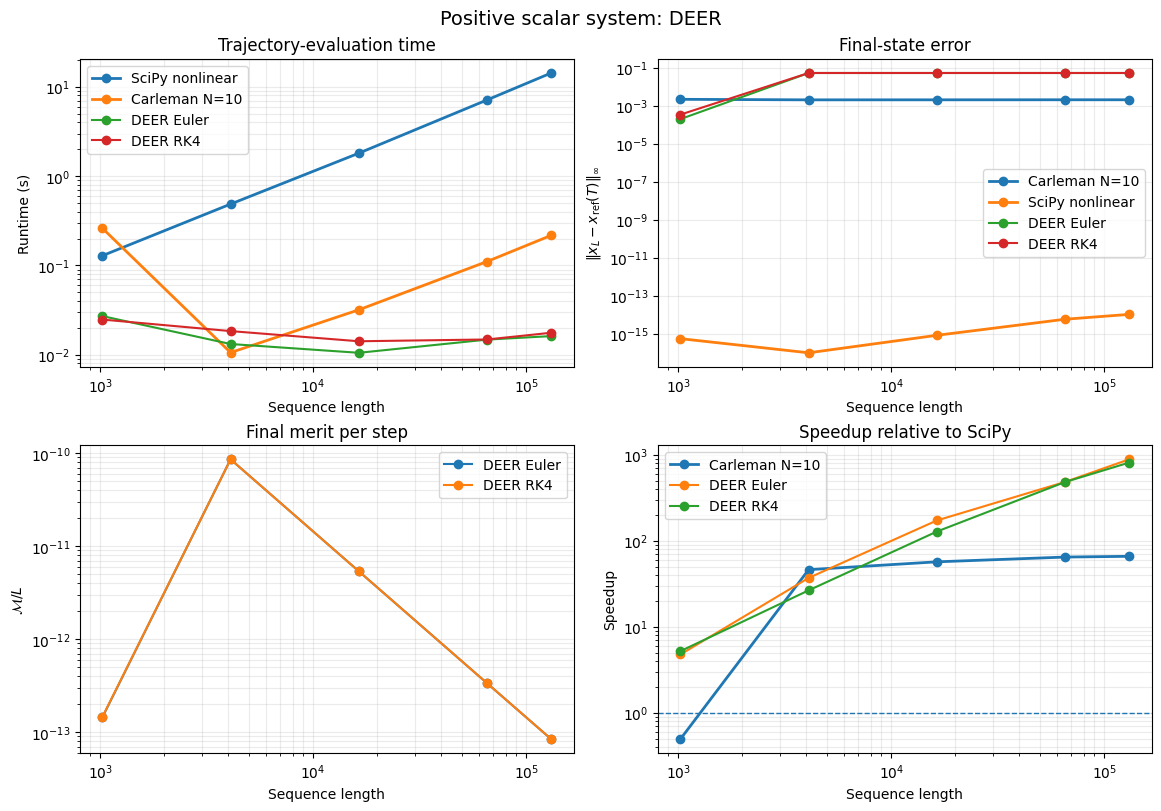

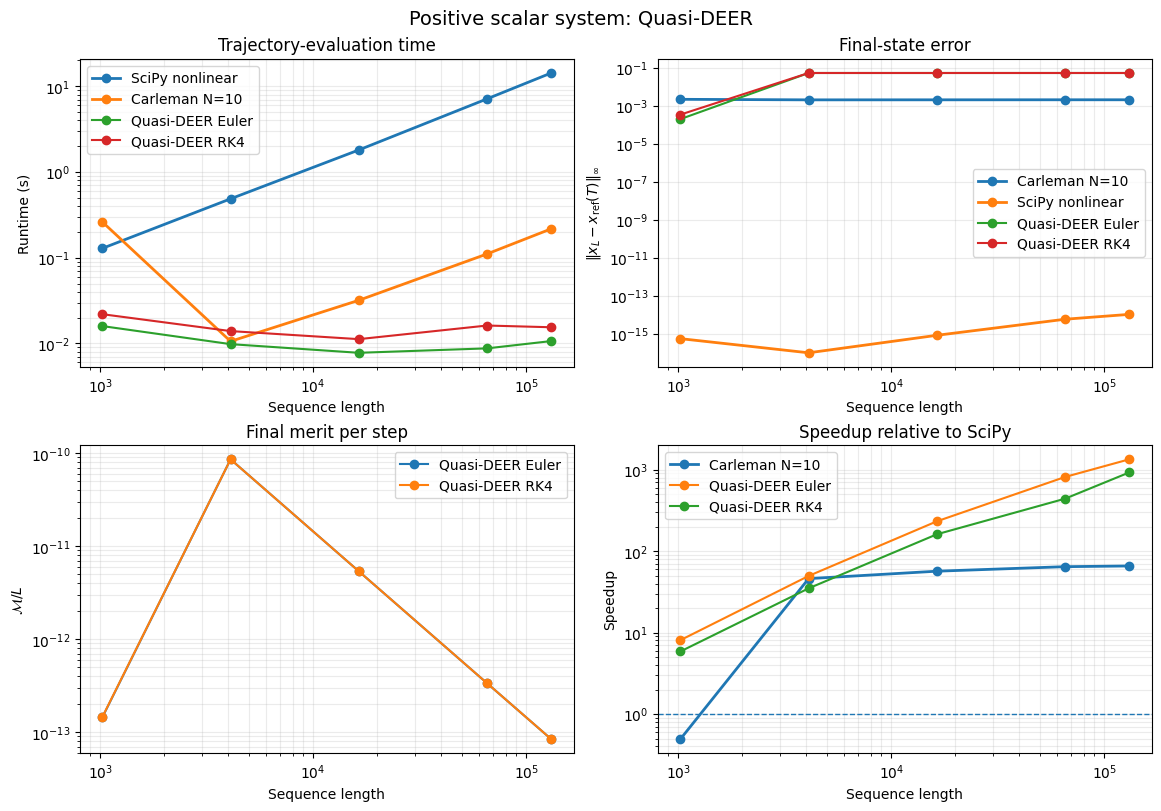

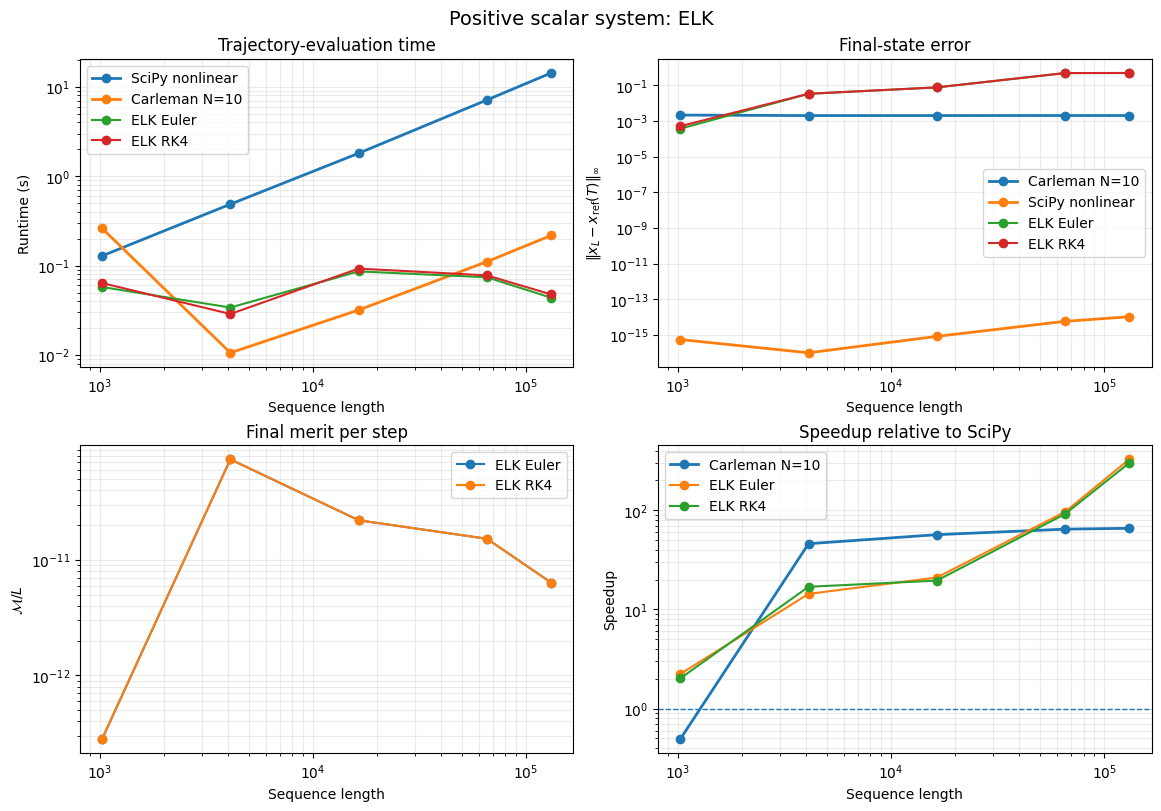

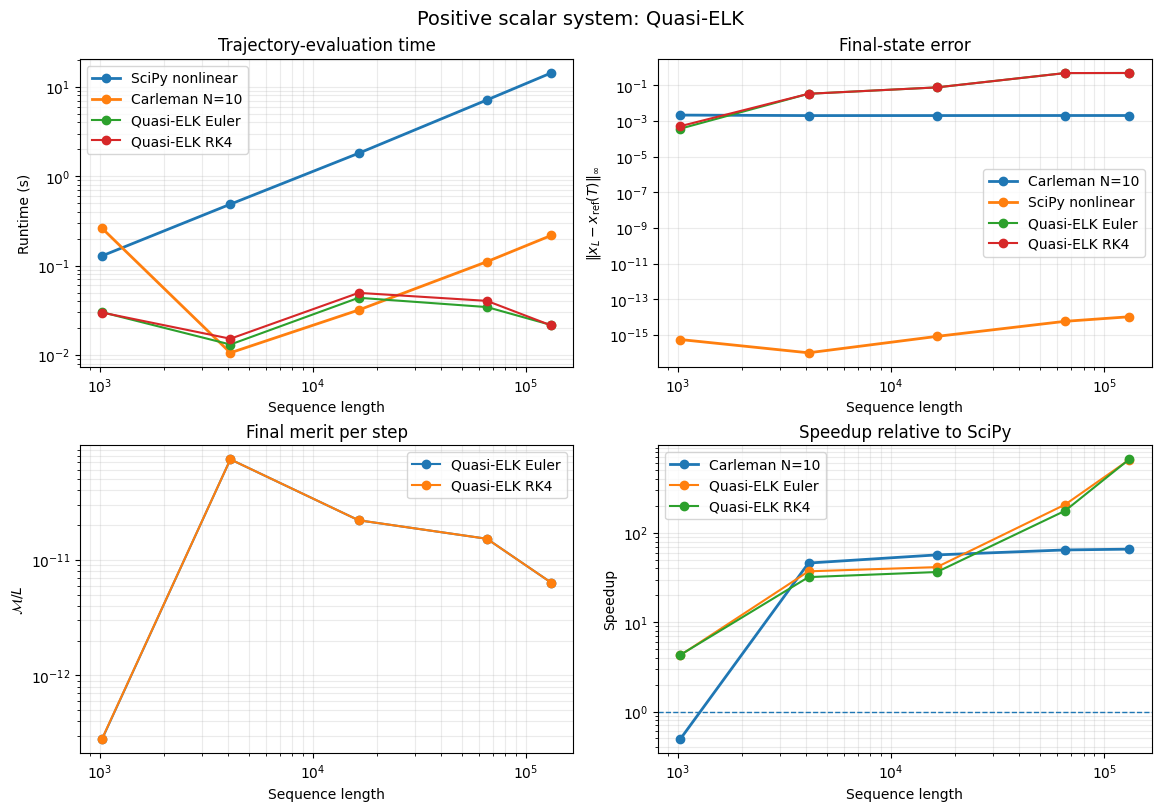

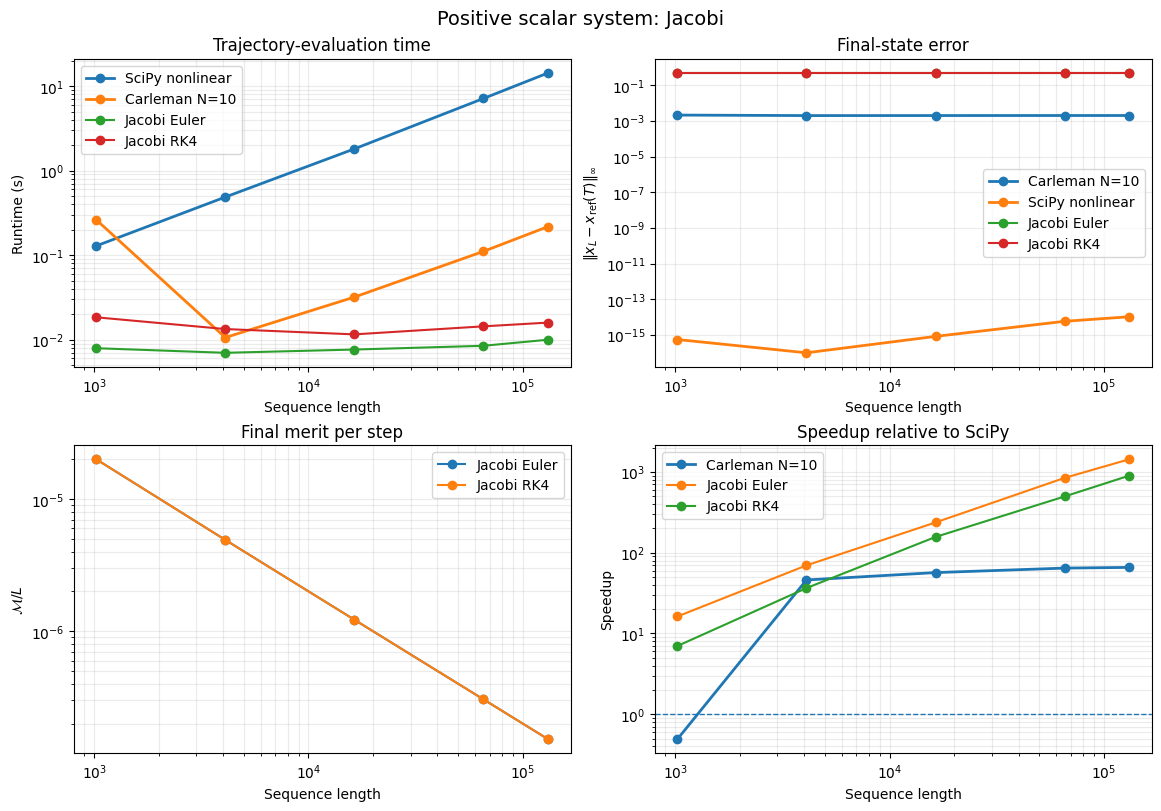

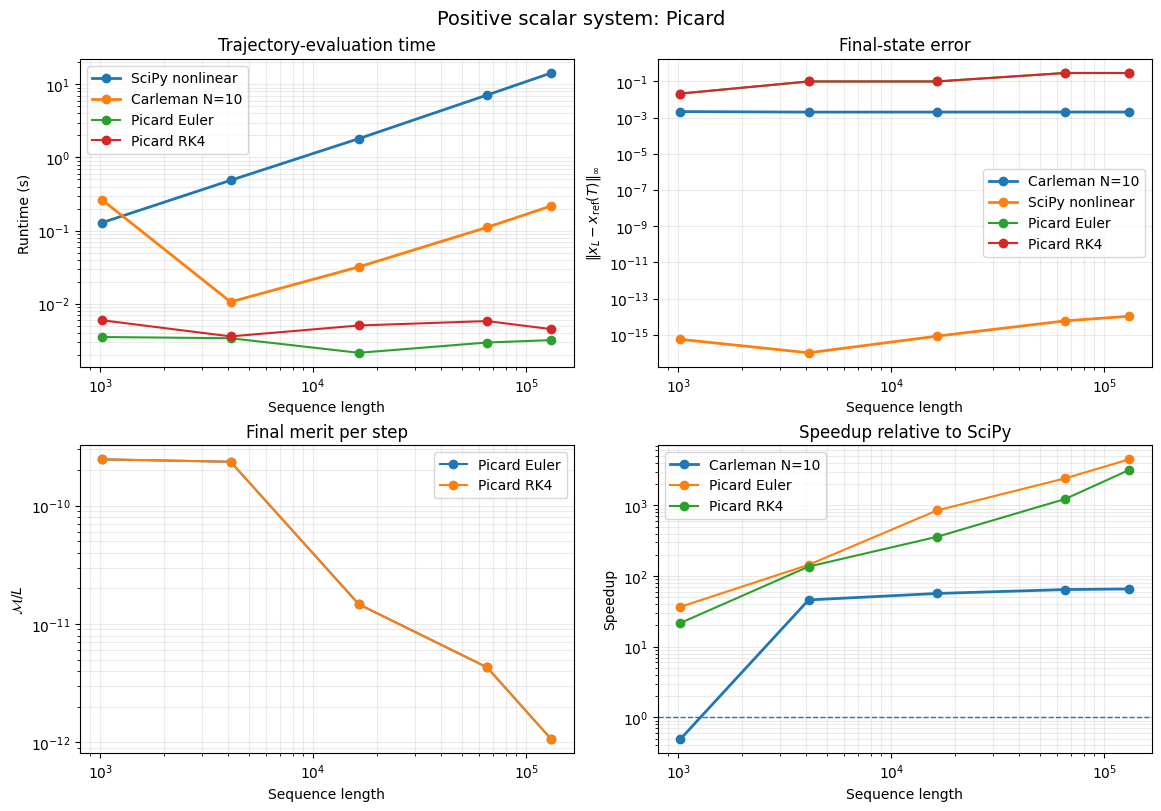

In [9]:
for method_name in method_specs:
    plot_method_benchmark(
        result=positive_scalar_results,
        method_name=method_name,
        system_name="Positive scalar system",
    )

# Negative scalar system

## Model

Stable scalar system:

$$
\dot{x}(t)=-\frac{x(t)}{1+x(t)^2},
\qquad
x(0)=x_0.
$$

Exact solution:

$$
x(t)=
\sqrt{
W\!\left(
x_0^2e^{x_0^2-2t}
\right)
}.
$$

Carleman matrix:

$$
(A_N)_{k\ell}
=
\begin{cases}
-k(-1)^{(\ell-k)/2},
&
\ell\geq k,\quad \ell-k\ \text{even},
\\[3pt]
0,
&
\text{otherwise}.
\end{cases}
$$

Benchmark parameters: $x_0=0.2$, $T=10$, $N=3$.

In [10]:
negative_scalar_initial = np.array([0.2], dtype=np.float64)
negative_scalar_final_time = 10.0
negative_scalar_order = 3


def negative_scalar_rhs_torch(time, state, control):
    return -state / (1.0 + state**2)


def negative_scalar_rhs_scipy(time, state):
    return -state / (1.0 + state**2)


negative_scalar_reference_final = scalar_exact_final(
    initial=negative_scalar_initial[0],
    final_time=negative_scalar_final_time,
    sign=-1.0,
)
negative_scalar_matrix = scalar_carleman_matrix(
    order=negative_scalar_order,
    sign=-1.0,
)
negative_scalar_lifted_initial = scalar_lift(
    initial=negative_scalar_initial[0],
    order=negative_scalar_order,
)

print(f"Reference final state: {negative_scalar_reference_final}")
print(f"Carleman dimension:    {negative_scalar_matrix.shape[0]}")

Reference final state: [9.26341384e-06]
Carleman dimension:    3


## Simulation

In [11]:
negative_scalar_results = benchmark_system(
    system_name="Negative scalar system",
    rhs_torch=negative_scalar_rhs_torch,
    rhs_scipy=negative_scalar_rhs_scipy,
    initial_state=negative_scalar_initial,
    final_time=negative_scalar_final_time,
    reference_final=negative_scalar_reference_final,
    carleman_matrix=negative_scalar_matrix,
    lifted_initial=negative_scalar_lifted_initial,
    carleman_order=negative_scalar_order,
    output_dimension=1,
)

Negative scalar system: completed L = 1,024
Negative scalar system: completed L = 4,096
Negative scalar system: completed L = 16,384
Negative scalar system: completed L = 65,536
Negative scalar system: completed L = 131,072


## Results

In [12]:
display_summary(negative_scalar_results)

,Sequence length,Category,Method,Integrator,Runtime (s),Speedup vs SciPy,Final error,Final merit,Merit per step,Iterations,Repeats
0,1024,Linear estimate,Carleman N=3,lsim ZOH,0.011113,11.290506,2.247566e-09,NaN,NaN,1.0,1
1,1024,Parallel nonlinear,DEER,EULER,0.012270,10.226017,6.155953e-07,4.757173e-08,4.645677e-11,1.0,3
2,1024,Parallel nonlinear,DEER,RK4,0.016643,7.539134,1.804585e-07,4.605819e-08,4.497870e-11,1.0,3
3,1024,Parallel nonlinear,ELK,EULER,0.029805,4.209783,6.197081e-07,4.763107e-08,4.651471e-11,1.0,3
4,1024,Parallel nonlinear,ELK,RK4,0.032245,3.891195,1.848032e-07,4.611532e-08,4.503450e-11,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...
65,131072,Parallel nonlinear,Quasi-DEER,EULER,0.011208,1335.692926,1.942292e-07,3.861680e-10,2.946228e-15,1.0,1
66,131072,Parallel nonlinear,Quasi-DEER,RK4,0.013014,1150.374554,1.942292e-07,3.872086e-10,2.954167e-15,1.0,1
67,131072,Parallel nonlinear,Quasi-ELK,EULER,0.018582,805.660239,9.246155e-06,8.650784e-08,6.600024e-13,1.0,1
68,131072,Parallel nonlinear,Quasi-ELK,RK4,0.024007,623.613185,9.246155e-06,8.652225e-08,6.601124e-13,1.0,1


In [13]:
runtime_table(negative_scalar_results)

Label,Carleman N=3,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4,SciPy DOP853
Sequence length,,,,,,,,,,,,,,
1024,0.011113,0.012270,0.016643,0.029805,0.032245,0.008495,0.016141,0.007859,0.016569,0.008856,0.014312,0.015094,0.016585,0.125471
4096,0.012068,0.013290,0.017448,0.047508,0.039497,0.006684,0.012627,0.007419,0.013404,0.010299,0.014993,0.019752,0.019570,0.502429
16384,0.029635,0.010857,0.013705,0.029469,0.032857,0.006616,0.014165,0.006590,0.014432,0.008448,0.010137,0.015591,0.018679,1.884897
65536,0.109533,0.015247,0.015151,0.038902,0.039549,0.008772,0.014405,0.011147,0.016713,0.010523,0.015785,0.018908,0.023156,7.426338
131072,0.211673,0.015280,0.016285,0.044714,0.047089,0.007528,0.014569,0.009105,0.015396,0.011208,0.013014,0.018582,0.024007,14.970945


In [14]:
error_table(negative_scalar_results)

Label,Carleman N=3,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4,SciPy DOP853
Sequence length,,,,,,,,,,,,,,
1024,2.247566e-09,6.155953e-07,1.804585e-07,6.197081e-07,1.848032e-07,0.000009,0.000009,2.069912,2.060216,6.155953e-07,1.804585e-07,6.197253e-07,1.847804e-07,5.082198e-21
4096,1.727335e-09,2.929430e-07,1.843330e-07,3.632096e-07,2.554636e-07,0.000009,0.000009,2.087952,2.085545,2.929430e-07,1.843330e-07,3.632260e-07,2.555337e-07,1.524659e-20
16384,3.621813e-09,2.120898e-07,1.849732e-07,1.285829e-06,1.262384e-06,0.000009,0.000009,2.092457,2.091878,2.120898e-07,1.849732e-07,1.285592e-06,1.262259e-06,3.388132e-20
65536,1.284500e-08,1.942010e-07,1.942010e-07,7.864276e-06,7.864276e-06,0.000009,0.000009,2.093565,2.093460,1.942010e-07,1.942010e-07,7.864255e-06,7.864255e-06,1.694066e-20
131072,1.287501e-08,1.942292e-07,1.942292e-07,9.246156e-06,9.246156e-06,0.000009,0.000009,2.094012,2.093958,1.942292e-07,1.942292e-07,9.246155e-06,9.246155e-06,6.606857e-20


In [15]:
merit_table(negative_scalar_results)

Label,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4
Sequence length,,,,,,,,,,,,
1024,4.645677e-11,4.497870e-11,4.651471e-11,4.503450e-11,1.526741e-05,1.528402e-05,1.594985e-05,1.587050e-05,4.645677e-11,4.497870e-11,4.651565e-11,4.503355e-11
4096,2.973672e-12,2.953744e-12,3.037611e-12,3.017267e-12,4.593073e-06,4.593379e-06,1.005716e-06,1.004494e-06,2.973672e-12,2.953744e-12,3.037602e-12,3.017467e-12
16384,1.871228e-13,1.868569e-13,2.723442e-13,2.721200e-13,1.202208e-06,1.202213e-06,6.299483e-08,6.297645e-08,1.871228e-13,1.868569e-13,2.722944e-13,2.720939e-13
65536,1.173936e-14,1.180409e-14,3.375819e-13,3.379430e-13,3.040137e-07,3.040138e-07,3.939308e-09,3.939094e-09,1.173936e-14,1.180409e-14,3.375747e-13,3.379338e-13
131072,2.946228e-15,2.954167e-15,6.600172e-13,6.601306e-13,1.522971e-07,1.522971e-07,9.850522e-10,9.850241e-10,2.946228e-15,2.954167e-15,6.600024e-13,6.601124e-13


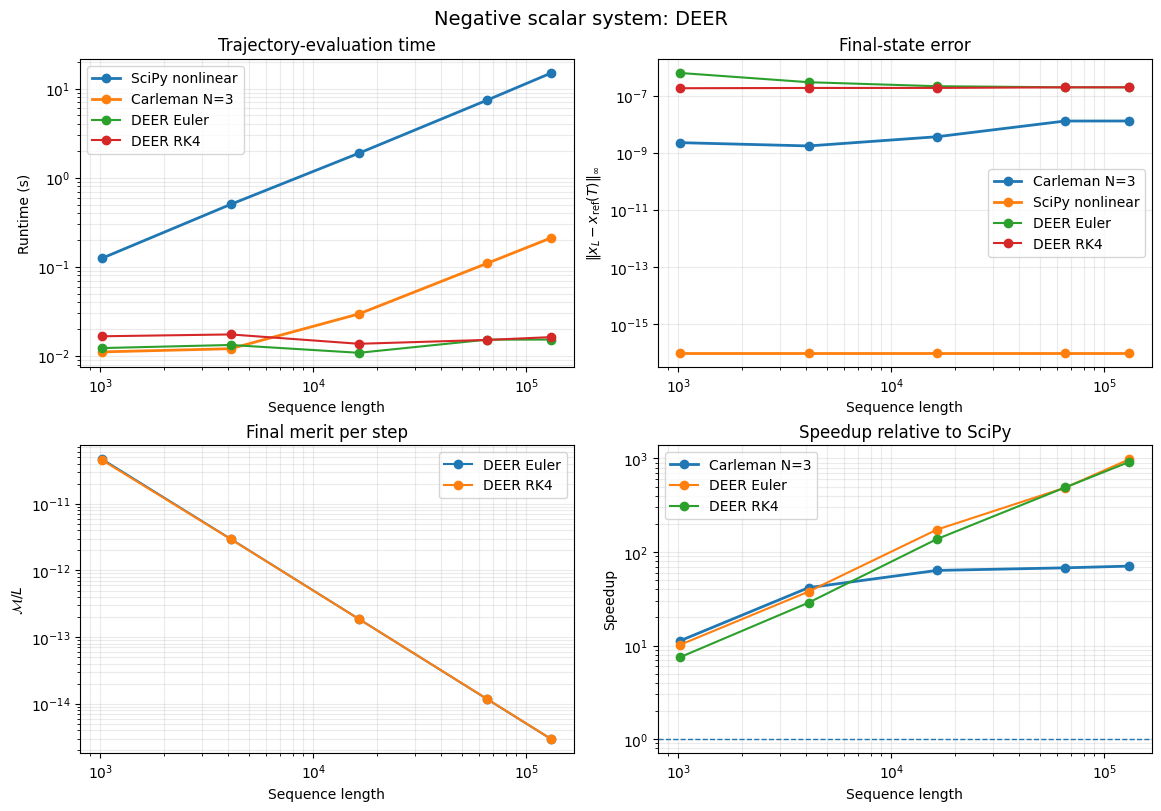

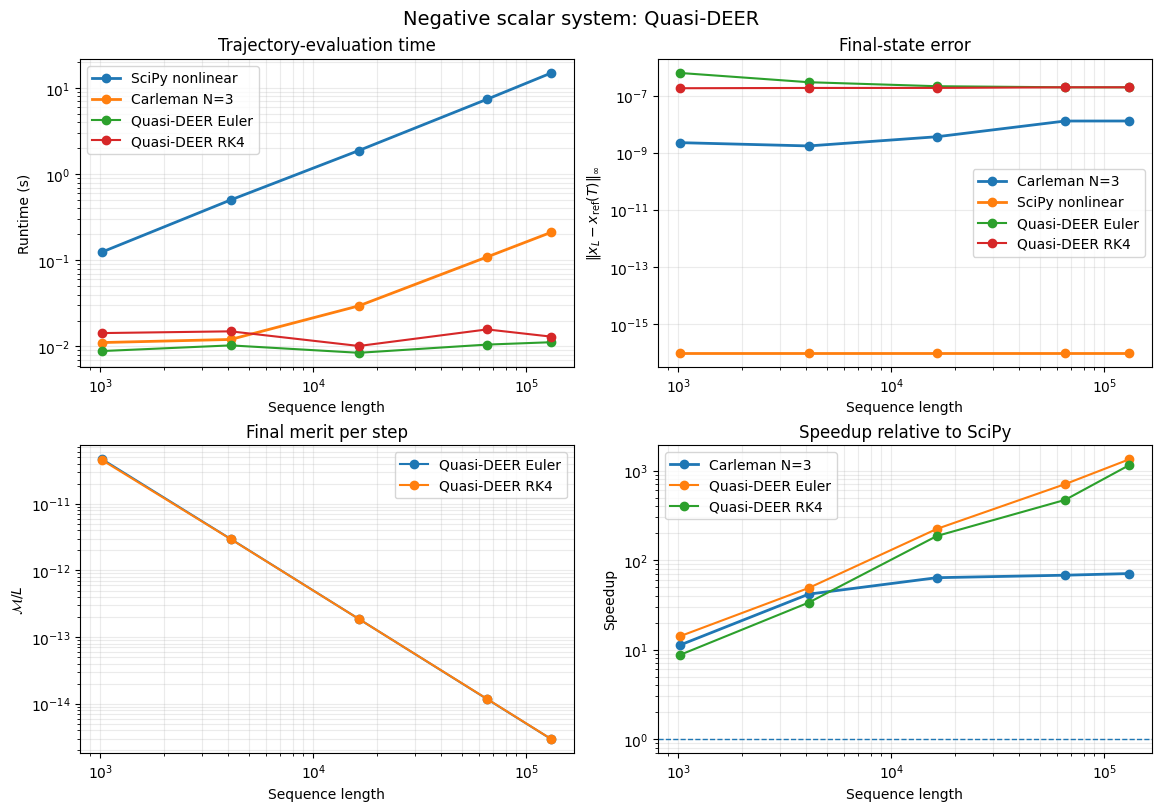

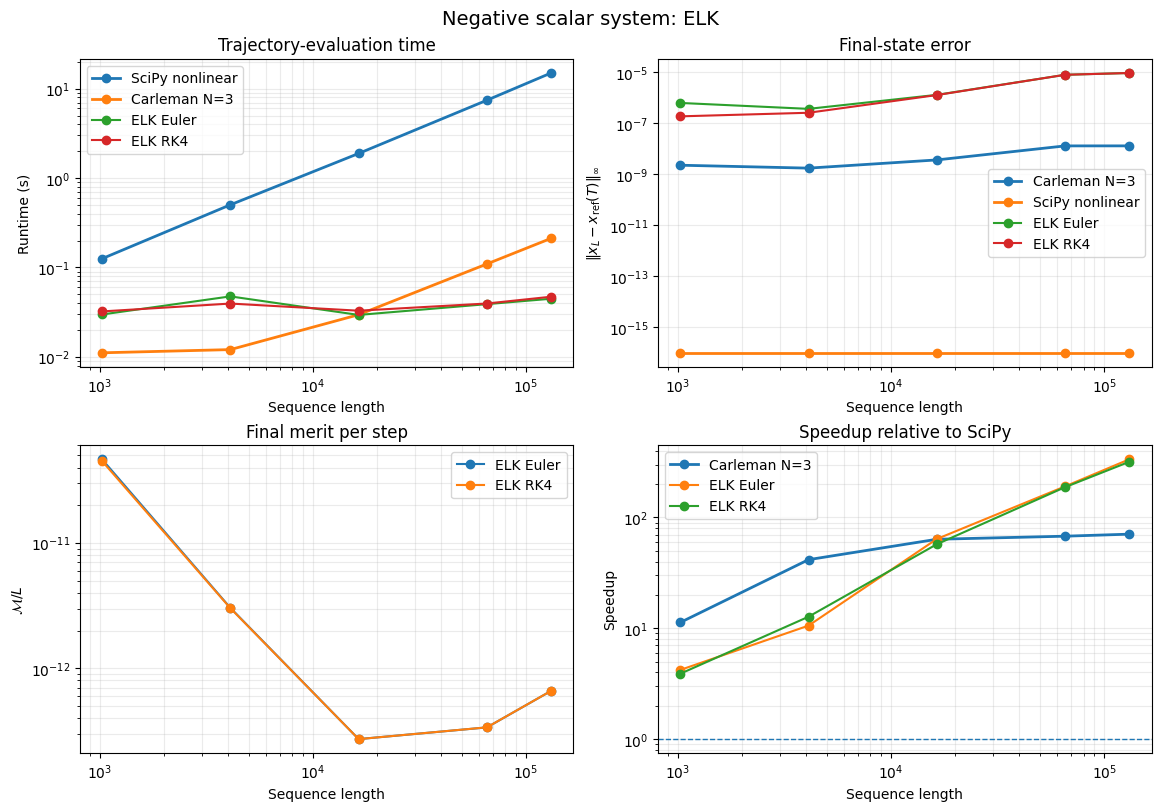

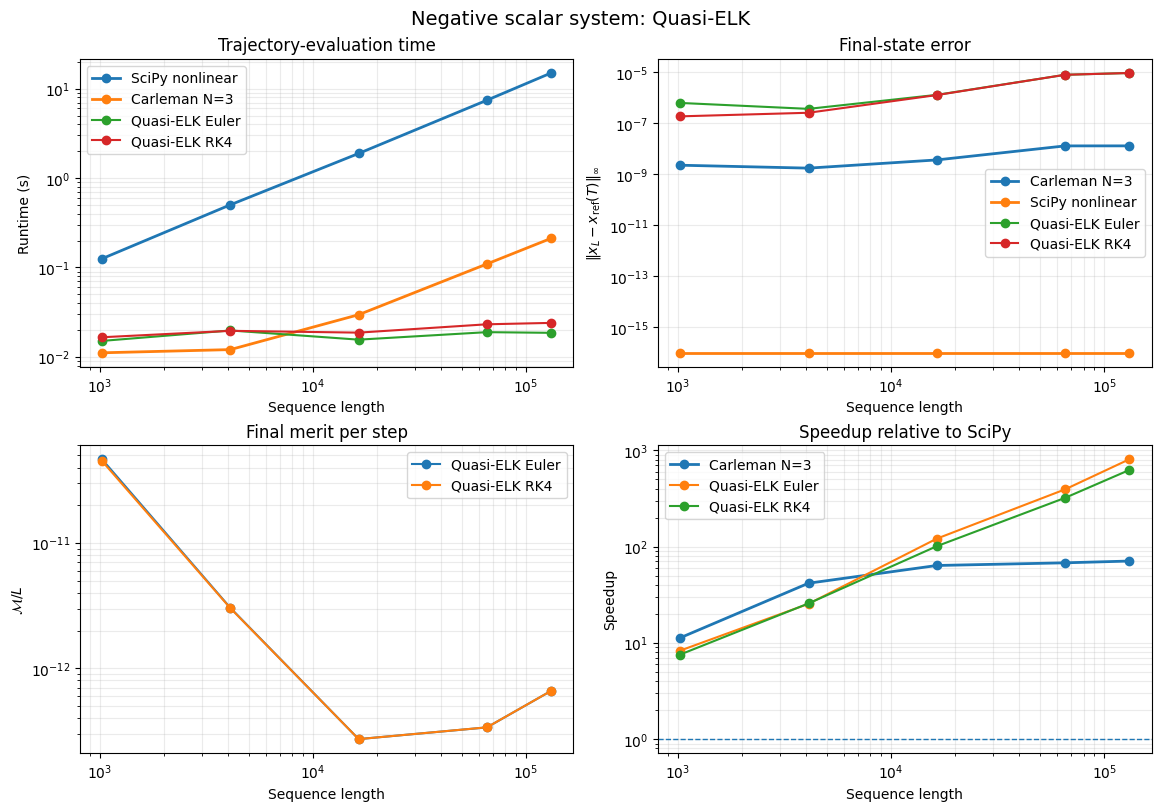

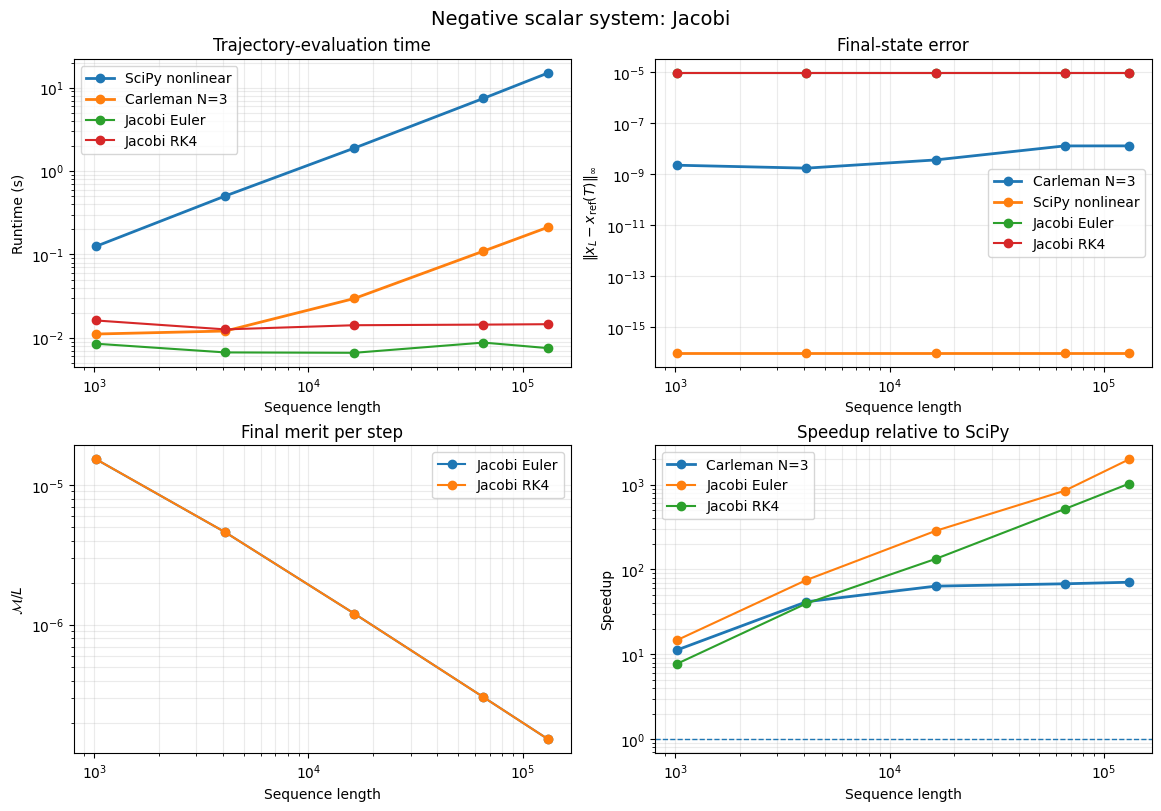

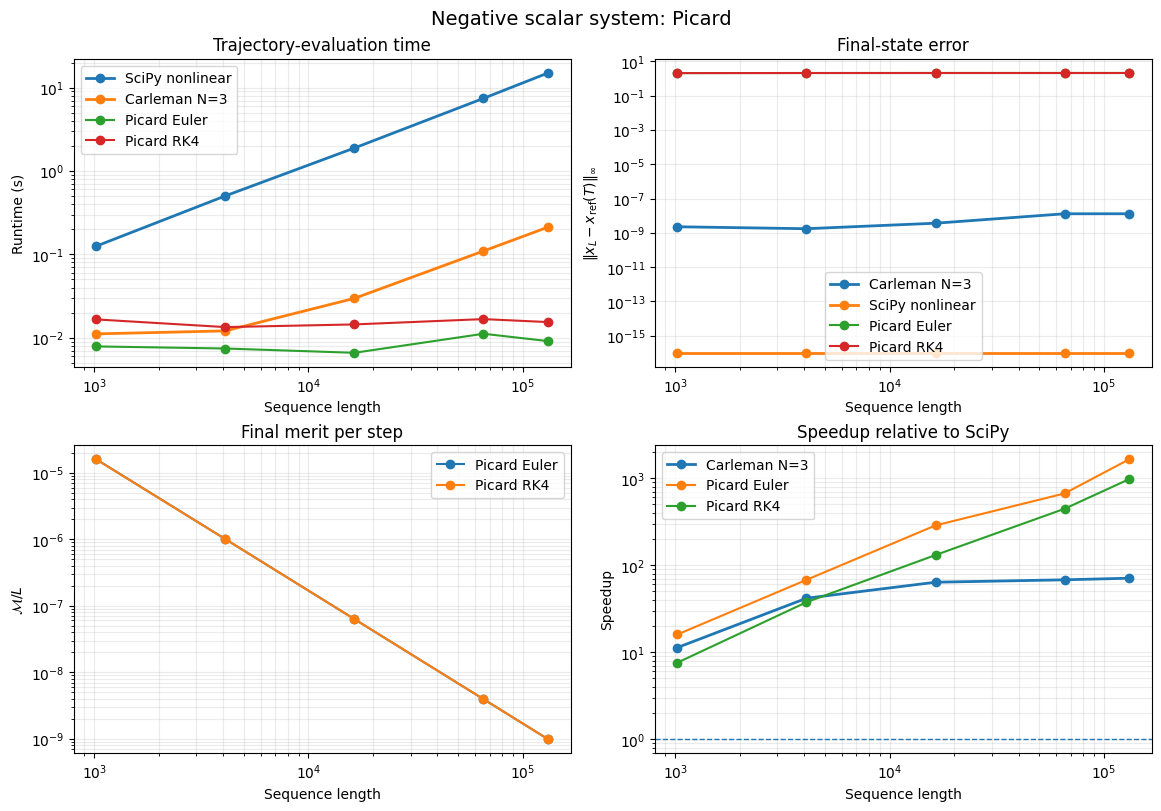

In [16]:
for method_name in method_specs:
    plot_method_benchmark(
        result=negative_scalar_results,
        method_name=method_name,
        system_name="Negative scalar system",
    )

# Van der Pol oscillator

## Model

Van der Pol oscillator:

$$
\ddot{x}
-
\mu(1-x^2)\dot{x}
+
x
=
0.
$$

With $x_1=x$ and $x_2=\dot{x}$,

$$
\dot{x}_1=x_2,
\qquad
\dot{x}_2=-x_1+\mu(1-x_1^2)x_2.
$$

Lifted block ordering for degree $k$:

$$
z_k=
\begin{bmatrix}
x_1^k &
x_1^{k-1}x_2 &
\cdots &
x_2^k
\end{bmatrix}^{T}.
$$

Rows for $x_1^{k-b}x_2^b$:

$$
(A_{k,k})_{b,b+1}=k-b,
\qquad
(A_{k,k})_{b,b-1}=-b,
\qquad
(A_{k,k})_{b,b}=\mu b,
$$

and

$$
(A_{k,k+2})_{b,b}=-\mu b.
$$

Finite-section dimension:

$$
\sum_{k=1}^{N}(k+1)
=
\frac{N(N+3)}{2}.
$$

Benchmark parameters: $\mu=0.5$, $x(0)=[2,-1]^T$, $T=0.1$, $N=5$.

In [17]:
vdp_mu = 0.5
vdp_initial = np.array([2.0, -1.0], dtype=np.float64)
vdp_final_time = 0.1
vdp_order = 5


def vdp_rhs_torch(time, state, control):
    x1 = state[..., 0]
    x2 = state[..., 1]

    return torch.stack(
        (
            x2,
            -x1 + vdp_mu * (1.0 - x1**2) * x2,
        ),
        dim=-1,
    )


def vdp_rhs_scipy(time, state):
    x1, x2 = state

    return np.array(
        [
            x2,
            -x1 + vdp_mu * (1.0 - x1**2) * x2,
        ],
        dtype=np.float64,
    )


def vdp_reference_final(initial, final_time):
    solution = solve_ivp(
        vdp_rhs_scipy,
        (0.0, final_time),
        initial,
        t_eval=[final_time],
        method="DOP853",
        rtol=1e-13,
        atol=1e-15,
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution.y[:, -1]


def vdp_block_offsets(order):
    offsets = {}
    dimension = 0

    for degree in range(1, order + 1):
        offsets[degree] = dimension
        dimension += degree + 1

    return offsets, dimension


def vdp_carleman_matrix(order, mu):
    offsets, dimension = vdp_block_offsets(order)
    rows = []
    columns = []
    values = []

    for degree in range(1, order + 1):
        offset = offsets[degree]

        for velocity_power in range(degree + 1):
            row = offset + velocity_power

            if velocity_power < degree:
                rows.append(row)
                columns.append(offset + velocity_power + 1)
                values.append(degree - velocity_power)

            if velocity_power > 0:
                rows.extend([row, row])
                columns.extend(
                    [
                        offset + velocity_power - 1,
                        offset + velocity_power,
                    ]
                )
                values.extend(
                    [
                        -velocity_power,
                        mu * velocity_power,
                    ]
                )

                if degree + 2 <= order:
                    rows.append(row)
                    columns.append(
                        offsets[degree + 2] + velocity_power
                    )
                    values.append(-mu * velocity_power)

    return csr_matrix(
        (values, (rows, columns)),
        shape=(dimension, dimension),
        dtype=np.float64,
    )


def vdp_lift(initial, order):
    x1, x2 = initial
    lifted = []

    for degree in range(1, order + 1):
        for velocity_power in range(degree + 1):
            lifted.append(
                x1 ** (degree - velocity_power)
                * x2**velocity_power
            )

    return np.asarray(lifted, dtype=np.float64)


vdp_reference = vdp_reference_final(
    initial=vdp_initial,
    final_time=vdp_final_time,
)
vdp_matrix = vdp_carleman_matrix(
    order=vdp_order,
    mu=vdp_mu,
)
vdp_lifted_initial = vdp_lift(
    initial=vdp_initial,
    order=vdp_order,
)

print(f"Reference final state: {vdp_reference}")
print(f"Carleman dimension:    {vdp_matrix.shape[0]}")

Reference final state: [ 1.89745375 -1.05143217]
Carleman dimension:    20


## Simulation

In [18]:
vdp_results = benchmark_system(
    system_name="Van der Pol oscillator",
    rhs_torch=vdp_rhs_torch,
    rhs_scipy=vdp_rhs_scipy,
    initial_state=vdp_initial,
    final_time=vdp_final_time,
    reference_final=vdp_reference,
    carleman_matrix=vdp_matrix,
    lifted_initial=vdp_lifted_initial,
    carleman_order=vdp_order,
    output_dimension=2,
)

Van der Pol oscillator: completed L = 1,024
Van der Pol oscillator: completed L = 4,096
Van der Pol oscillator: completed L = 16,384
Van der Pol oscillator: completed L = 65,536
Van der Pol oscillator: completed L = 131,072


## Results

In [19]:
display_summary(vdp_results)

,Sequence length,Category,Method,Integrator,Runtime (s),Speedup vs SciPy,Final error,Final merit,Merit per step,Iterations,Repeats
0,1024,Linear estimate,Carleman N=5,lsim ZOH,0.015422,9.159727,1.080712e-03,NaN,NaN,1.0,1
1,1024,Parallel nonlinear,DEER,EULER,0.024996,5.651355,1.049439e-04,2.301448e-11,2.247508e-14,2.0,3
2,1024,Parallel nonlinear,DEER,RK4,0.038759,3.644648,1.038710e-04,2.292921e-11,2.239181e-14,2.0,3
3,1024,Parallel nonlinear,ELK,EULER,0.075334,1.875163,4.465183e-04,1.962377e-10,1.916384e-13,2.0,3
4,1024,Parallel nonlinear,ELK,RK4,0.082030,1.722101,4.461606e-04,1.956195e-10,1.910347e-13,2.0,3
...,...,...,...,...,...,...,...,...,...,...,...
65,131072,Parallel nonlinear,Quasi-DEER,EULER,0.013919,1046.365840,1.025455e-01,4.169558e-08,3.181120e-13,1.0,1
66,131072,Parallel nonlinear,Quasi-DEER,RK4,0.017089,852.270334,1.025455e-01,4.391595e-08,3.350521e-13,1.0,1
67,131072,Parallel nonlinear,Quasi-ELK,EULER,0.205249,70.960779,1.096688e+00,1.338050e-05,1.020851e-10,12.0,1
68,131072,Parallel nonlinear,Quasi-ELK,RK4,0.243665,59.773234,1.096694e+00,1.337156e-05,1.020169e-10,12.0,1


In [20]:
runtime_table(vdp_results)

Label,Carleman N=5,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4,SciPy DOP853
Sequence length,,,,,,,,,,,,,,
1024,0.015422,0.024996,0.038759,0.075334,0.082030,0.011995,0.024225,0.003653,0.007610,0.020257,0.032254,0.033729,0.041410,0.141264
4096,0.012263,0.028256,0.039484,0.077567,0.063799,0.008506,0.019485,0.002820,0.006163,0.024227,0.031529,0.027379,0.033583,0.519935
16384,0.027897,0.023907,0.031259,0.162314,0.158333,0.008164,0.019434,0.003023,0.005263,0.011496,0.014478,0.060599,0.074059,1.879636
65536,0.114248,0.014076,0.020493,0.842608,0.809106,0.010069,0.023518,0.007440,0.008701,0.009940,0.016176,0.163445,0.192979,7.316195
131072,0.215823,0.014903,0.021752,1.669257,1.635127,0.010272,0.021223,0.011074,0.014193,0.013919,0.017089,0.205249,0.243665,14.564659


In [21]:
error_table(vdp_results)

Label,Carleman N=5,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4,SciPy DOP853
Sequence length,,,,,,,,,,,,,,
1024,0.001081,0.000105,0.000104,0.000447,0.000446,1.897454,1.897454,0.002571,0.002571,0.005003,0.005001,0.004616,0.004614,5.329071e-15
4096,0.000850,0.000115,0.000115,0.006788,0.006789,1.897454,1.897454,0.002449,0.002449,0.005024,0.005023,0.002542,0.002559,7.327472e-15
16384,0.001780,0.000088,0.000143,0.032603,0.032603,1.897454,1.897454,0.102540,0.102540,0.102540,0.102540,0.027378,0.027377,2.198242e-14
65536,0.001941,0.195839,0.195839,0.136169,0.136148,1.897454,1.897454,0.102545,0.102545,0.102545,0.102545,0.132749,0.132738,1.798561e-14
131072,0.001964,0.195840,0.213904,1.106926,1.106925,1.897454,1.897454,0.102546,0.102546,0.102546,0.102546,1.096688,1.096694,1.021405e-14


In [22]:
merit_table(vdp_results)

Label,DEER EULER,DEER RK4,ELK EULER,ELK RK4,Jacobi EULER,Jacobi RK4,Picard EULER,Picard RK4,Quasi-DEER EULER,Quasi-DEER RK4,Quasi-ELK EULER,Quasi-ELK RK4
Sequence length,,,,,,,,,,,,
1024,2.247508e-14,2.239181e-14,1.916384e-13,1.910347e-13,0.002440,0.002440,5.263845e-12,5.269549e-12,1.757582e-11,1.756956e-11,1.477116e-11,1.476557e-11
4096,9.029236e-15,8.770762e-15,4.698937e-12,4.692812e-12,0.000610,0.000610,3.343922e-13,3.345518e-13,1.110582e-12,1.110501e-12,4.391505e-13,4.403596e-13
16384,7.000910e-15,7.137520e-15,6.333663e-12,6.330690e-12,0.000153,0.000153,2.328306e-11,2.328306e-11,1.969144e-11,1.969153e-11,5.258047e-12,5.260801e-12
65536,5.089758e-12,5.089764e-12,8.812032e-12,8.797019e-12,0.000038,0.000038,1.456590e-12,1.456590e-12,1.202062e-12,1.202062e-12,8.725401e-12,8.706166e-12
131072,1.278414e-12,1.515413e-12,1.018341e-10,1.017570e-10,0.000019,0.000019,3.197418e-13,3.197418e-13,3.181120e-13,3.350521e-13,1.020851e-10,1.020169e-10


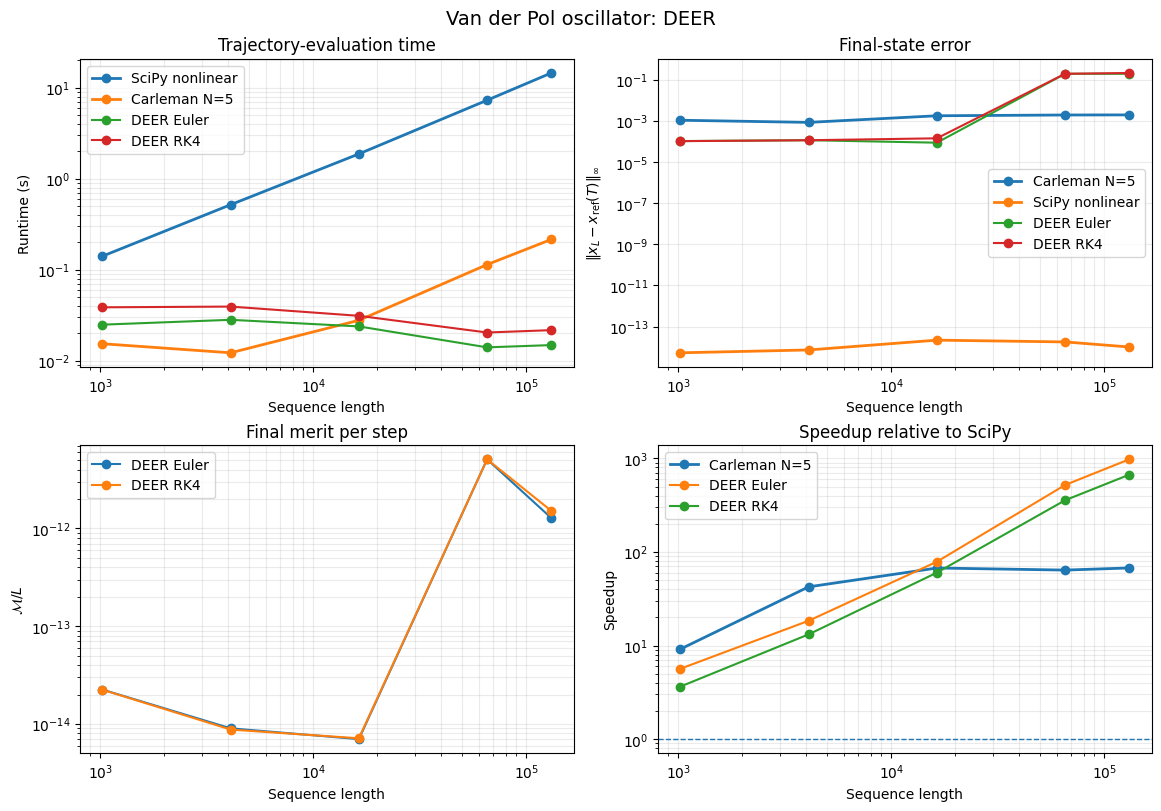

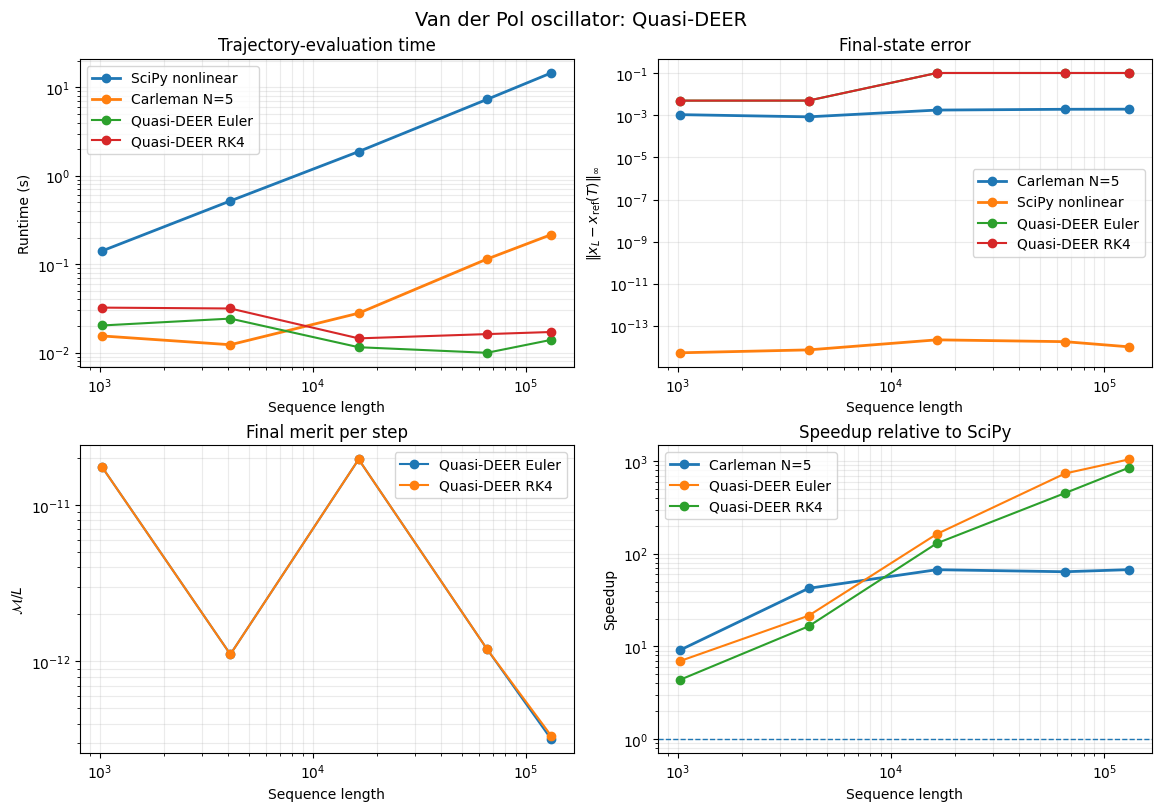

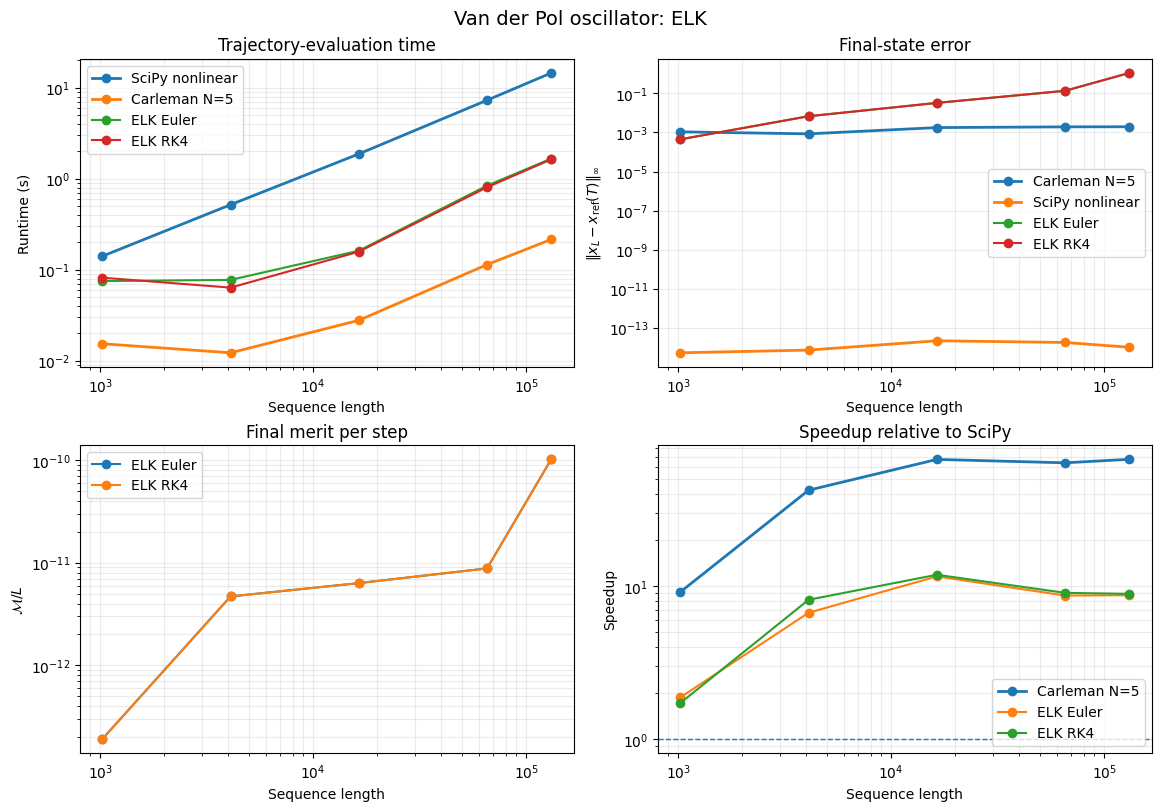

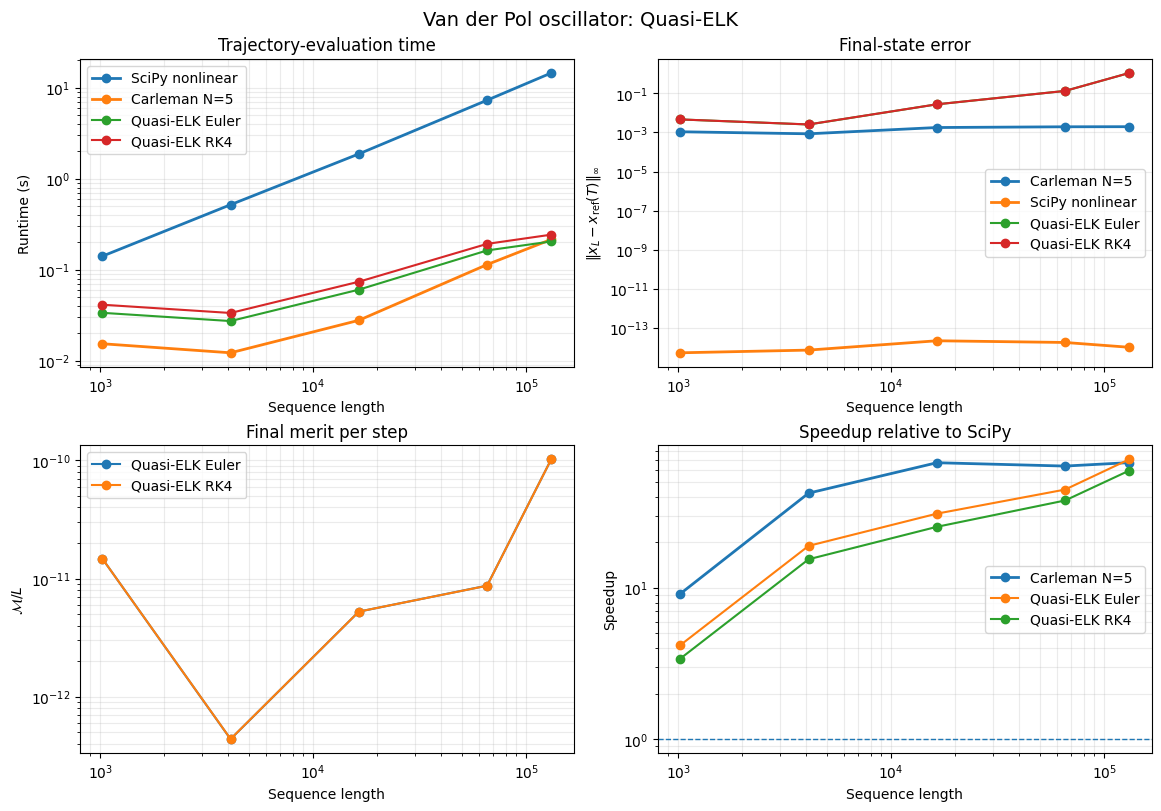

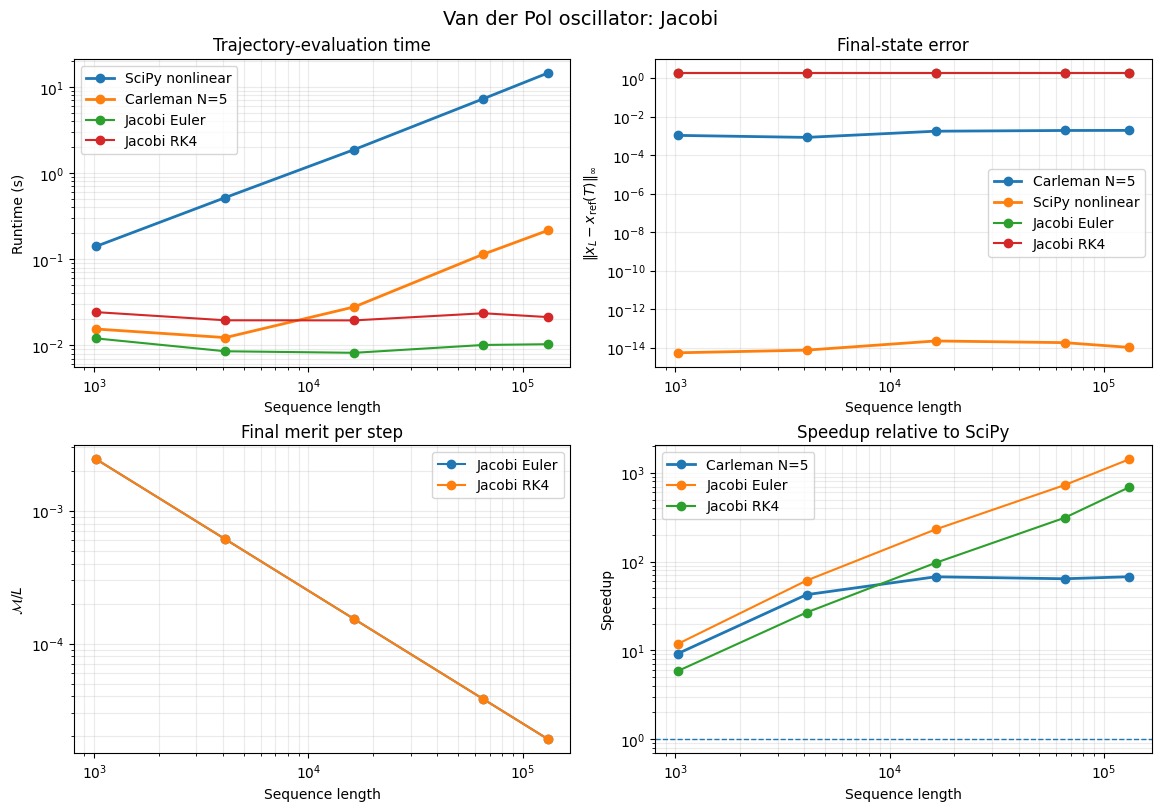

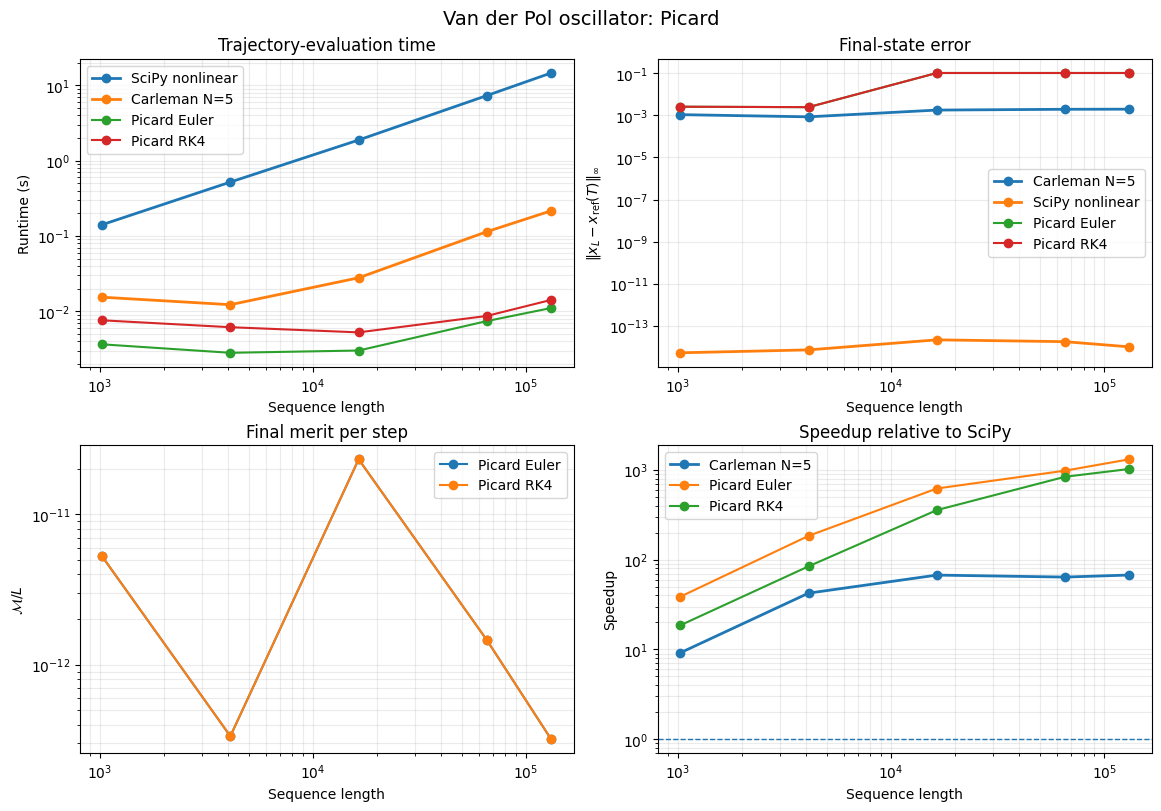

In [23]:
for method_name in method_specs:
    plot_method_benchmark(
        result=vdp_results,
        method_name=method_name,
        system_name="Van der Pol oscillator",
    )

# Combined results

In [24]:
all_results = pd.concat(
    [
        positive_scalar_results,
        negative_scalar_results,
        vdp_results,
    ],
    ignore_index=True,
)

all_results.to_csv(
    "Carleman_Benchmarking_results.csv",
    index=False,
)

display_summary(all_results)

,Sequence length,Category,Method,Integrator,Runtime (s),Speedup vs SciPy,Final error,Final merit,Merit per step,Iterations,Repeats
0,1024,Linear estimate,Carleman N=10,lsim ZOH,0.261512,0.491690,2.143684e-03,NaN,NaN,1.0,1
1,1024,Linear estimate,Carleman N=3,lsim ZOH,0.011113,11.290506,2.247566e-09,NaN,NaN,1.0,1
2,1024,Linear estimate,Carleman N=5,lsim ZOH,0.015422,9.159727,1.080712e-03,NaN,NaN,1.0,1
3,1024,Parallel nonlinear,DEER,EULER,0.027109,4.743094,1.953872e-04,1.473793e-10,1.439251e-13,2.0,3
4,1024,Parallel nonlinear,DEER,EULER,0.012270,10.226017,6.155953e-07,4.757173e-08,4.645677e-11,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...
205,131072,Parallel nonlinear,Quasi-ELK,RK4,0.024007,623.613185,9.246155e-06,8.652225e-08,6.601124e-13,1.0,1
206,131072,Parallel nonlinear,Quasi-ELK,RK4,0.243665,59.773234,1.096694e+00,1.337156e-05,1.020169e-10,12.0,1
207,131072,Sequential nonlinear,SciPy DOP853,Adaptive,14.282853,1.000000,1.049161e-14,NaN,NaN,NaN,1
208,131072,Sequential nonlinear,SciPy DOP853,Adaptive,14.970945,1.000000,6.606857e-20,NaN,NaN,NaN,1
